TESTING

TODO:
- run `just r` on test_files/modifier_examples/justfile
- calling the test `test_saved_hugr` in `tket/src/modifier/modifier_resolver.rs` 
- run `just r` on `test_files/run_modifier_examples`

In [ ]:

!uv pip install "guppylang == 0.21.11"


Audited 1 package in 11ms


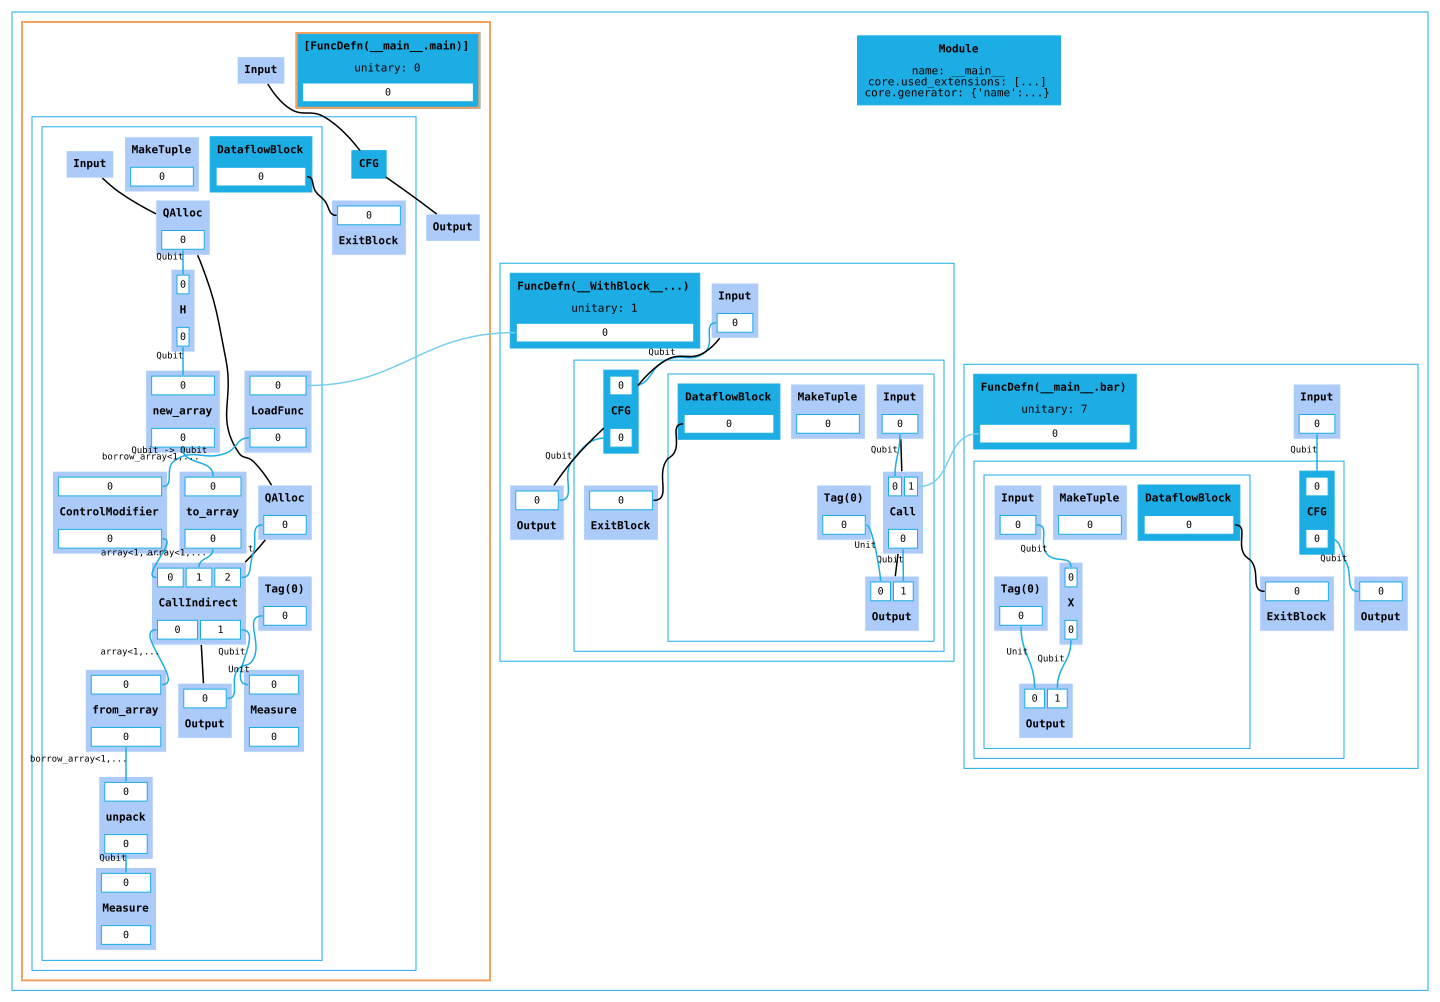

In [10]:

"""A simple controlled gate using modifiers"""

from pathlib import Path
from sys import argv

from guppylang import guppy
from guppylang.std.builtins import control
from guppylang.std.quantum import qubit
from guppylang.std.qsystem import measure
from guppylang.std.quantum import h, x

from guppylang.experimental import enable_experimental_features

enable_experimental_features()


@guppy(unitary=True)
def bar(q: qubit) -> None:
    x(q)


@guppy
def main() -> None:
    q1 = qubit()
    q2 = qubit()
    h(q1)
    with control(q1):
        bar(q2)

    measure(q1)
    measure(q2)


main.compile().modules[0].render_dot()
# Path(argv[0]).with_suffix(".hugr").write_bytes(program.to_bytes())
